In [271]:
import numpy as np
import matplotlib.pyplot as plt
import keras

In [272]:
(train_data, train_label), (test_data, test_label) = keras.datasets.mnist.load_data()
train_data.shape, train_label.shape, test_data.shape, test_label.shape

((60000, 28, 28), (60000,), (10000, 28, 28), (10000,))

5


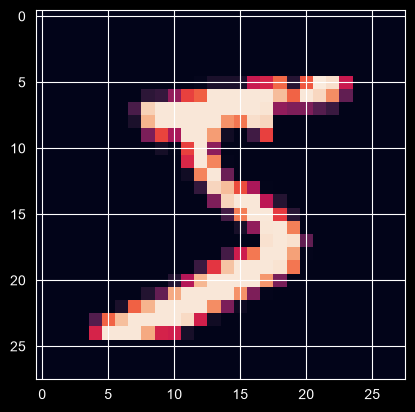

In [273]:
i = 0
print(train_label[i])
plt.imshow(train_data[i])
plt.show()

In [274]:
train_data = train_data.reshape((60000, 28*28))
train_data = train_data.astype("float32")/255.0

test_data = test_data.reshape((10000, 28*28))
test_data = test_data.astype("float32")/255.0

train_data.shape, test_data.shape

((60000, 784), (10000, 784))

In [275]:
model = keras.Sequential(
    [
        keras.layers.Dense(784, activation="relu"),
        keras.layers.Dense(10, activation="softmax")
    ]
)

In [276]:
model.compile(loss="sparse_categorical_crossentropy", optimizer="adam", metrics=["accuracy"])

In [277]:
epochs = 30
history = model.fit(train_data, train_label, epochs=epochs, batch_size=256, validation_split=0.2)

Epoch 1/30
188/188 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.8923 - loss: 6760.6548 - val_accuracy: 0.9245 - val_loss: 2630.3452
Epoch 2/30
188/188 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.9527 - loss: 1157.4342 - val_accuracy: 0.9483 - val_loss: 1346.4756
Epoch 3/30
188/188 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.9688 - loss: 531.7384 - val_accuracy: 0.9567 - val_loss: 1059.1855
Epoch 4/30
188/188 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.9775 - loss: 328.6485 - val_accuracy: 0.9590 - val_loss: 941.9706
Epoch 5/30
188/188 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.9796 - loss: 265.9407 - val_accuracy: 0.9595 - val_loss: 883.5472
Epoch 6/30
188/188 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.9833 - loss: 193.9178 - val_accuracy: 0.9646 - val_loss: 926.3088
Epoch 7/30
188/188 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.9842 - loss: 186.7175 - val_accuracy: 0.9662 - val_loss: 853.4442
Epoch 8/30
188/188 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy:

In [278]:
loss, accuracy = model.evaluate(test_data, test_label)
loss, accuracy

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9720 - loss: 891.0225


(891.0225219726562, 0.972000002861023)

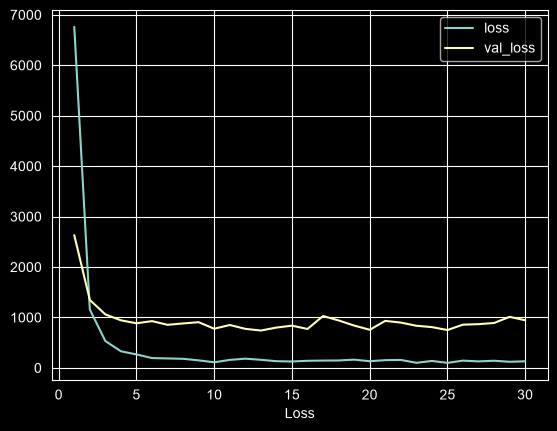

In [279]:
epochs_x = range(1, epochs+1)
plt.plot(epochs_x, history.history["loss"], label="loss")
plt.plot(epochs_x, history.history["val_loss"], label="val_loss")
plt.xlabel("Epochs")
plt.xlabel("Loss")
plt.legend()
plt.show()

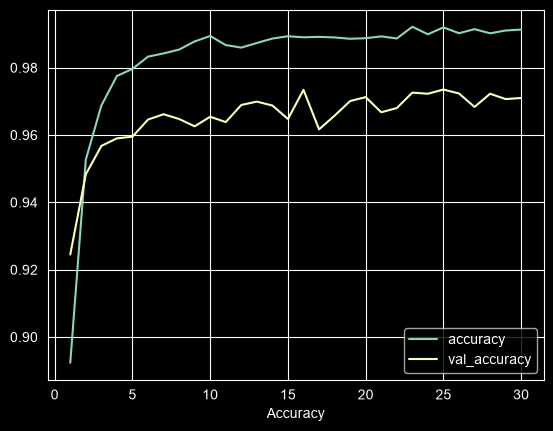

In [280]:
epochs_x = range(1, epochs+1)
plt.plot(epochs_x, history.history["accuracy"], label="accuracy")
plt.plot(epochs_x, history.history["val_accuracy"], label="val_accuracy")
plt.xlabel("Epochs")
plt.xlabel("Accuracy")
plt.legend()
plt.show()